<h1 align="center" style="font-size:60px;"><b>
Protecting IoT Devices from Network Attacks
</b></h1>

In [1]:
import kagglehub
path = kagglehub.dataset_download("vigneshvenkateswaran/bot-iot")
print("Path to dataset files:", path)

100%|██████████| 1.17G/1.17G [00:17<00:00, 73.5MB/s]

Extracting files...


Path to dataset files: /root/.cache/kagglehub/datasets/vigneshvenkateswaran/bot-iot/versions/1


In [2]:
import pandas as pd
import numpy as np
import os
import glob


from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split

In [3]:

DATA_DIR = path

csv_files = glob.glob(os.path.join(DATA_DIR, "**", "*.csv"), recursive=True)

print("Total CSV files found:", len(csv_files))

Total CSV files found: 75


In [4]:
#data preprocessing
df_list = []

for file in csv_files:
    print("Processing:", os.path.basename(file))

    for chunk in pd.read_csv(file, chunksize=200000, low_memory=False):

        # If subcategory exists, stratify by it
        if 'subcategory' in chunk.columns:
            sampled_chunk = chunk.groupby('subcategory', group_keys=False)\
                                 .apply(lambda x: x.sample(frac=0.05, random_state=42))
        else:
            sampled_chunk = chunk.sample(frac=0.05, random_state=42)

        df_list.append(sampled_chunk)

df = pd.concat(df_list, ignore_index=True)

print("\nDataset safely loaded!")
print("Final Shape:", df.shape)
print("Memory Usage (GB):", df.memory_usage(deep=True).sum() / (1024**3))

Processing: data_49.csv
Processing: data_73.csv
Processing: data_55.csv
Processing: data_5.csv
Processing: data_43.csv
Processing: data_45.csv
Processing: data_12.csv
Processing: data_35.csv
Processing: data_34.csv
Processing: data_47.csv
Processing: data_63.csv
Processing: data_23.csv
Processing: data_21.csv
Processing: data_61.csv
Processing: data_22.csv
Processing: data_30.csv
Processing: data_32.csv
Processing: data_52.csv
Processing: data_27.csv
Processing: data_53.csv
Processing: data_3.csv
Processing: data_68.csv
Processing: data_33.csv
Processing: data_1.csv
Processing: data_9.csv
Processing: data_18.csv
Processing: data_72.csv
Processing: data_64.csv
Processing: data_19.csv
Processing: data_31.csv
Processing: data_57.csv
Processing: data_28.csv
Processing: data_74.csv
Processing: data_69.csv
Processing: data_58.csv
Processing: data_41.csv
Processing: data_60.csv
Processing: data_67.csv
Processing: data_66.csv
Processing: data_17.csv
Processing: data_40.csv
Processing: data_29.

/tmp/ipykernel_680/2159668984.py:18: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  df = pd.concat(df_list, ignore_index=True)



Dataset safely loaded!
Final Shape: (3668522, 35)
Memory Usage (GB): 3.1846047500148416


In [5]:
print(df.columns.tolist())

['pkSeqID', 'stime', 'flgs', 'proto', 'saddr', 'sport', 'daddr', 'dport', 'pkts', 'bytes', 'state', 'ltime', 'seq', 'dur', 'mean', 'stddev', 'smac', 'dmac', 'sum', 'min', 'max', 'soui', 'doui', 'sco', 'dco', 'spkts', 'dpkts', 'sbytes', 'dbytes', 'rate', 'srate', 'drate', 'attack', 'category', 'subcategory ']


In [6]:
print("Unique categories:")
print(df['category'].unique())

Unique categories:
['DDoS' 'Normal' 'DoS' 'Reconnaissance' 'Theft']


In [7]:
#Feature selection

X = df.drop(columns=[
    'category',
    'pkSeqID',
    'stime',
    'ltime',
    'saddr',
    'daddr',
    'smac',
    'dmac',
    'attack',
    'subcategory '
], errors='ignore')

y = df['category']

In [8]:
# Remove invalid values
X = X.replace([np.inf, -np.inf], np.nan)
X = X.fillna(0)

print("Total NaN values after cleaning:", X.isna().sum().sum())

/tmp/ipykernel_680/2161650161.py:2: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  X = X.replace([np.inf, -np.inf], np.nan)


Total NaN values after cleaning: 0


In [9]:
from sklearn.preprocessing import LabelEncoder

# Encode feature columns
for col in X.select_dtypes(include='object').columns:
    X[col] = LabelEncoder().fit_transform(X[col].astype(str))

In [10]:
label_encoder = LabelEncoder()
y_encoded = label_encoder.fit_transform(y)

print("Class Mapping:")
print(dict(zip(label_encoder.classes_, range(len(label_encoder.classes_)))))

Class Mapping:
{'DDoS': 0, 'DoS': 1, 'Normal': 2, 'Reconnaissance': 3, 'Theft': 4}


In [11]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y_encoded,
    test_size=0.2,
    random_state=42,
    stratify=y_encoded
)

print("Train shape:", X_train.shape)
print("Test shape:", X_test.shape)

Train shape: (2934817, 25)
Test shape: (733705, 25)


In [12]:
from sklearn.preprocessing import StandardScaler

# Feature standardization
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Convert to float32 for deep learning
X_train_scaled = X_train_scaled.astype('float32')
X_test_scaled = X_test_scaled.astype('float32')

# Reshape data for Conv1D (ConvNeXt)
X_train_dl = X_train_scaled.reshape(X_train_scaled.shape[0], X_train_scaled.shape[1], 1)
X_test_dl = X_test_scaled.reshape(X_test_scaled.shape[0], X_test_scaled.shape[1], 1)

print("DL Train Shape:", X_train_dl.shape)
print("DL Test Shape:", X_test_dl.shape)
print("Standardization and reshaping completed successfully!")

DL Train Shape: (2934817, 25, 1)
DL Test Shape: (733705, 25, 1)
Standardization and reshaping completed successfully!


In [13]:
import tensorflow as tf
from tensorflow.keras.layers import Input, Conv1D, LayerNormalization
from tensorflow.keras.models import Model

In [14]:
def convnext_block(x, filters):

    x = Conv1D(filters=filters, kernel_size=3, padding='same')(x)
    x = LayerNormalization()(x)
    x = tf.keras.layers.Activation('gelu')(x)

    return x

In [15]:
input_layer = Input(shape=(X_train_dl.shape[1], 1))

# ConvNeXt Feature Extraction
x = convnext_block(input_layer, 64)
x = convnext_block(x, 128)

In [16]:
  from tensorflow.keras.layers import Bidirectional, LSTM

  # BiLSTM Layer
  x = Bidirectional(LSTM(64, return_sequences=False))(x)

In [17]:
from tensorflow.keras.layers import Dense, Dropout

# Dense layers
x = Dropout(0.3)(x)
x = Dense(64, activation='relu')(x)

In [18]:
output_layer = Dense(5, activation='softmax')(x)

In [19]:
from tensorflow.keras.models import Model

model = Model(inputs=input_layer, outputs=output_layer)

In [20]:
from tensorflow.keras.optimizers import Adam

model.compile(
    optimizer=Adam(learning_rate=0.0003),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 25, 1)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d (Conv1D)                 │ (None, 25, 64)         │           256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ layer_normalization             │ (None, 25, 64)         │           128 │
│ (LayerNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation (Activation)         │ (None, 25, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_1 (Conv1D)               │ (None, 25, 128)        │        24,704 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ layer_normalization_1           │ (None, 25, 128)        │           256 │
│ (LayerNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_1 (Activation)       │ (None, 25, 128)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional (Bidirectional)   │ (None, 128)            │        98,816 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 5)              │           325 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 132,741 (518.52 KB)

 Trainable params: 132,741 (518.52 KB)

 Non-trainable params: 0 (0.00 B)

In [21]:
from tensorflow.keras.callbacks import EarlyStopping

early_stop = EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True)

history = model.fit(
    X_train_dl,
    y_train,
    validation_data=(X_test_dl, y_test),
    epochs=10,
    batch_size=512,
    callbacks=[early_stop]
)

Epoch 1/10
5733/5733 ━━━━━━━━━━━━━━━━━━━━ 108s 18ms/step - accuracy: 0.8452 - loss: 0.3303 - val_accuracy: 0.9279 - val_loss: 0.1635
Epoch 2/10
5733/5733 ━━━━━━━━━━━━━━━━━━━━ 103s 18ms/step - accuracy: 0.9365 - loss: 0.1490 - val_accuracy: 0.9411 - val_loss: 0.1344
Epoch 3/10
5733/5733 ━━━━━━━━━━━━━━━━━━━━ 142s 18ms/step - accuracy: 0.9495 - loss: 0.1163 - val_accuracy: 0.9590 - val_loss: 0.0944
Epoch 4/10
5733/5733 ━━━━━━━━━━━━━━━━━━━━ 143s 18ms/step - accuracy: 0.9576 - loss: 0.0966 - val_accuracy: 0.9645 - val_loss: 0.0808
Epoch 5/10
5733/5733 ━━━━━━━━━━━━━━━━━━━━ 104s 18ms/step - accuracy: 0.9634 - loss: 0.0828 - val_accuracy: 0.9680 - val_loss: 0.0710
Epoch 6/10
5733/5733 ━━━━━━━━━━━━━━━━━━━━ 105s 18ms/step - accuracy: 0.9678 - loss: 0.0736 - val_accuracy: 0.9714 - val_loss: 0.0648
Epoch 7/10
5733/5733 ━━━━━━━━━━━━━━━━━━━━ 105s 18ms/step - accuracy: 0.9710 - loss: 0.0659 - val_accuracy: 0.9719 - val_loss: 0.0652
Epoch 8/10
5733/5733 ━━━━━━━━━━━━━━━━━━━━ 105s 18ms/step - accuracy: 

In [22]:
loss, accuracy = model.evaluate(X_test_dl, y_test)

print("Test Accuracy:", accuracy)
print("Test Loss:", loss)

22929/22929 ━━━━━━━━━━━━━━━━━━━━ 126s 5ms/step - accuracy: 0.9785 - loss: 0.0490
Test Accuracy: 0.9783346056938171
Test Loss: 0.04913010075688362


In [23]:
import numpy as np

y_pred = model.predict(X_test_dl)
y_pred_classes = np.argmax(y_pred, axis=1)

22929/22929 ━━━━━━━━━━━━━━━━━━━━ 74s 3ms/step


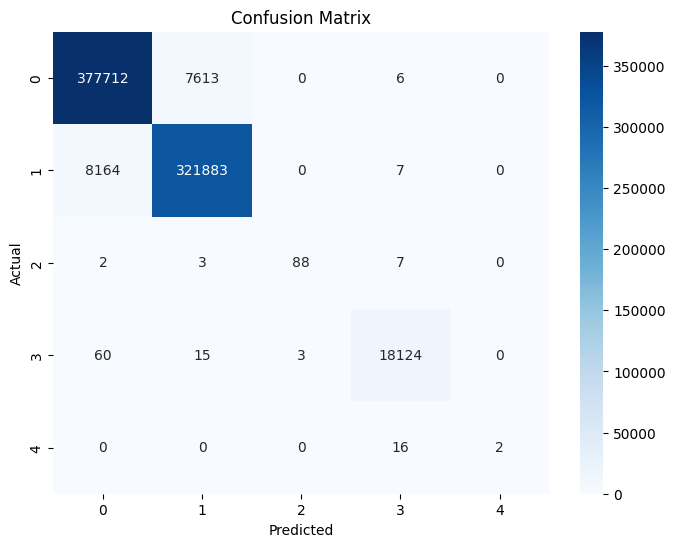

In [24]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred_classes)

plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

In [25]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred_classes))

              precision    recall  f1-score   support

           0       0.98      0.98      0.98    385331
           1       0.98      0.98      0.98    330054
           2       0.97      0.88      0.92       100
           3       1.00      1.00      1.00     18202
           4       1.00      0.11      0.20        18

    accuracy                           0.98    733705
   macro avg       0.98      0.79      0.81    733705
weighted avg       0.98      0.98      0.98    733705



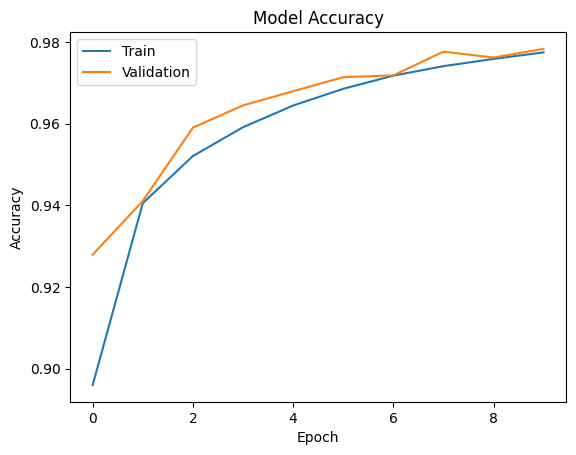

In [26]:
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title("Model Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend(["Train", "Validation"])
plt.show()

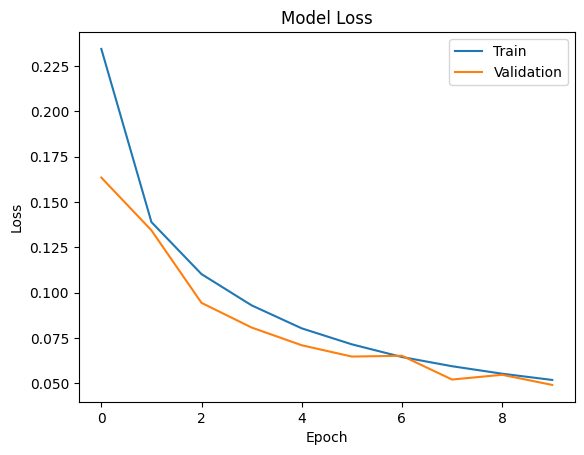

In [27]:
import matplotlib.pyplot as plt

plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title("Model Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend(["Train", "Validation"])
plt.show()